# 案例引入-神经网络案例引入（单层感知机模型）

## 手写实现的版本

In [2]:
import torch

In [6]:
# Tab键出现提示
# 输入数据
X = torch.tensor([
    [1,1,1],
    [1,0,1],
    [1,0,0],
    [1,1,0]],dtype=torch.float32)
# 输出的预测
y = torch.tensor([0.2,0.3,-0.3,0.15])

# 权重矩阵
W = torch.randn(3,1)

# 预测
# 使用mm函数进行矩阵相乘
yhat = torch.mm(X,W)
print("X = ",X)
print("W  = ",W)
print("yhat  = ",yhat)

X =  tensor([[1., 1., 1.],
        [1., 0., 1.],
        [1., 0., 0.],
        [1., 1., 0.]])
W  =  tensor([[0.3206],
        [0.3577],
        [0.4584]])
yhat  =  tensor([[1.1366],
        [0.7789],
        [0.3206],
        [0.6782]])


In [7]:
X.shape

torch.Size([4, 3])

In [8]:
W.shape

torch.Size([3, 1])

In [9]:
yhat.shape

torch.Size([4, 1])

In [ ]:
## 使用pytorch提供的api（函数），调用.nn.Linear

In [11]:
import torch
import torch.nn as nn

# 输入数据X
X = torch.tensor([
    [1,1,1],
    [1,0,1],
    [1,0,0],
    [1,1,0]],dtype=torch.float32)
# 输出的预测
y = torch.tensor([0.2,0.3,-0.3,0.15])

# nn.Linear(
#     in_features: int,
#     out_features: int,
#     bias: bool = True,
#     device=None,
#     dtype=None,
# ) -> None

# W: 3*1
linear_layer = nn.Linear(in_features=3,out_features=1)

# 计算预测
# 4*1
yhat = linear_layer(X)
yhat

tensor([[-0.0203],
        [ 0.1050],
        [ 0.2648],
        [ 0.1395]], grad_fn=<AddmmBackward0>)

In [12]:
yhat.shape

torch.Size([4, 1])

# 损失函数

## 回归损失 MSE Loss

In [13]:
# 它的作用是衡量模型预测值与真实值直接的差异
# 计算方式：先求出预测值和真实值之间的误差
# 然后对这个误差进行开平方操作
# 通过最小化这个均方误差，模型可以不断地调整自身的参数，使得预测值尽可能的接近真实值。


In [14]:
# 假设我们构建一个简单的线性回归模型（这里为了只是演示一下损失函数，我们不进行实际的训练）
# 我们假设一下y_pred = 1.5 * x
# 我们来计算一下MSE Loss

In [16]:
import torch
# 输出的x值
x = torch.tensor([1,2,3])
# 真实的y值
y = torch.tensor([2,4,6])
y_pred = 1.5 * x

y_pred

tensor([1.5000, 3.0000, 4.5000])

In [17]:
# 计算一下误差
erros = (y_pred - y) ** 2

In [18]:
erros

tensor([0.2500, 1.0000, 2.2500])

In [20]:
# 计算的是均方误差
mse_loss = torch.mean(erros)
mse_loss

tensor(1.1667)

## 交叉熵损失（分类）

In [21]:
import torch
import torch.nn as nn
# 定义损失函数
# nn.CrossEntropyLoss(
#     weight: Union[torch.Tensor, NoneType] = None,
#     size_average=None,
#     ignore_index: int = -100,
#     reduce=None,
#     reduction: str = 'mean',
#     label_smoothing: float = 0.0,
# ) -> None
# pascal voc2012 255
criterion = nn.CrossEntropyLoss()

In [22]:
criterion

CrossEntropyLoss()

In [ ]:
# 定义一下输入和目标标签

# batch为2
input1 = torch.tensor([
    [2.0,0.5],
    [0.5,2.0]
])
# 二分类
# 猫狗
# onehot变量

# 6个类别
# 0,1,2,3,4,5...

# 0表示的小猫
# 1表示的是小狗

# [2.0,0.5] -> 0 
# [0.5,2.9] -> 1

# batch为4
target1 = torch.tensor([0,1])

input2 = torch.tensor([
    [2.0,0.5],
    [0.5,2.0],
    [2.0,0.5],
    [0.5,2.0]
])

target2 = torch.tensor([0,1,0,1])


# 计算一下交叉熵损失
# 0,1,2,3,
# 
# output = loss(input, target)
loss1 = criterion(input1,target1)
loss2 = criterion(input2,target2)

print(f"Loss1 batch size 2: {loss1} ")
print(f"Loss2 batch size 4: {loss2} ")


Loss1 batch size 2: 0.2014133334159851 
Loss2 batch size 4: 0.2014133334159851 


# 激活函数

## sigmoid

In [25]:
# y_pred -> [0,1]
import torch
import torch.nn as nn

# 创建一个张量
# 是一个三分类
# 小猫、小狗、小猪
logits = torch.tensor([3,1,-3])
sigmoid = nn.Sigmoid()
y_pred = sigmoid(logits)

In [26]:
y_pred # softmax 

tensor([0.9526, 0.7311, 0.0474])

## softmax

In [31]:
# Shift + Tab
# 创建一个张量
# 是一个三分类

# Examples::

#     >>> m = nn.Softmax(dim=1)
#     >>> input = torch.randn(2, 3)
#     >>> output = m(input)

# 小猫、小狗、小猪
logits = torch.tensor([3.,1.,-3.])
softmax = nn.Softmax(dim=0)
y_pred = softmax(logits)


In [32]:
y_pred

tensor([0.8789, 0.1189, 0.0022])

In [33]:
## 二维
logits = torch.tensor([[3.,1.,-3.],[2.,0.,-2.]])

In [34]:
logits.shape

torch.Size([2, 3])

In [39]:
softmax = nn.Softmax(dim=1)
y_pred = softmax(logits)
y_pred

tensor([[0.8789, 0.1189, 0.0022],
        [0.8668, 0.1173, 0.0159]])

# 梯度下降

## 梯度下降的可视化，手写代码

In [1]:
import numpy as np
import matplotlib.pyplot as plt

theta_history =  [1, 0.19999999999999996, 0.03999999999999998, 0.007999999999999993]
theta: 1
theta: 0.19999999999999996
theta: 0.03999999999999998
theta: 0.007999999999999993


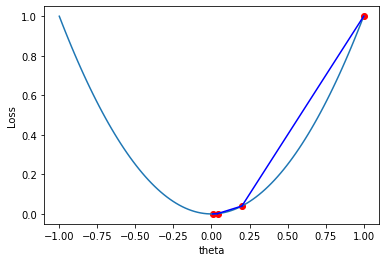

In [49]:


# 定义一下目标函数
# 损失函数
def J(theta):
    return theta ** 2

# 定义一下目标函数的导数
def J_deta(theta):
    return 2 * theta

# 定义一下梯度下降算法
def gradient_des(alpha,num_iters):
    theta = 1
    theta_history = []
    for i in range(num_iters):
        theta_history.append(theta)
        theta = theta - alpha * J_deta(theta)
    return theta_history


# 实现梯度下降
alpha = 0.4
num_iters = 4
theta_history = gradient_des(alpha,num_iters)
print("theta_history = ",theta_history)
# 打印一下每次迭代后的theta值
for i,theta in enumerate(theta_history):
    print(f"theta: {theta}")

# 绘制可视化图像
theta_values = np.linspace(-1,1,100)
J_values = J(theta_values)
plt.plot(theta_values,J_values)

for i,theta in enumerate(theta_history):
    plt.scatter(theta,J(theta),color='red')
    if i > 0:
#           Example:

#           >>> x = [1, 2, 3]
#           >>> y = np.array([[1, 2], [3, 4], [5, 6]])
#           >>> plot(x, y)
        plt.plot([theta_history[i-1],theta],[J(theta_history[i-1]),J(theta)],color="blue")
plt.xlabel("theta")
plt.ylabel("Loss")
plt.show()
        


# 使用卷积神经网络-实现手写数字识别

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim # 梯度下降（优化器）
from torchvision import datasets,transforms
import numpy as np



In [22]:
# 一些重要的超参数
# 每次训练需要多少个样本
# 100张图像
# 10 * 10次，才能真正遍历完一次数据集
batch_size = 64
learning_rate = 0.01
num_epochs = 30

# 数据进行一些预处理操作
# 我们需要把图像 img -> tensor

transform = transforms.Compose([
    transforms.ToTensor(),
    
])

# Args:
#     root (string): Root directory of dataset where ``MNIST/processed/training.pt``
#         and  ``MNIST/processed/test.pt`` exist.
#     train (bool, optional): If True, creates dataset from ``training.pt``,
#         otherwise from ``test.pt``.
#     download (bool, optional): If true, downloads the dataset from the internet and
#         puts it in root directory. If dataset is already downloaded, it is not
#         downloaded again.
#     transform (callable, optional): A function/transform that  takes in an PIL image
#         and returns a transformed version. E.g, ``transforms.RandomCrop``
#     target_transform (callable, optional): A function/transform that takes in the
#         target and transforms it.


# 训练数据集 train dataset 我们平时的测试题 
# train dataset : 图像 MNSIT img 对应label
# 验证数据集 valid dataset 我们的月考
# 测试数据集 test dataset 我们的高考



# 1.加载数据集
# 加载MNIST数据集
train_dataset = datasets.MNIST(root="./data",train=True,download=True,transform=transform) # 60K = 6w
test_dataset = datasets.MNIST(root="./data",train=False,download=True,transform=transform) # 10K = 1w

# DataLoader(dataset, batch_size=1, shuffle=False, sampler=None, num_workers=0, 
# collate_fn=default_collate, pin_memory=False, drop_last=False)

train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size,shuffle=False)


In [23]:
# MLP 全连接网络
# 图像
# 参数太大
# 缺少平移不变性

# [28,28]
# 28 * 28

# 2.搭建MLP网络
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN,self).__init__()
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(in_features=28*28,out_features=128)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(in_features=128,out_features=10)
    def forward(self,x):
#         print("输入进来的x的形状是: ",x.shape)
        out = self.flatten(x)
#         print("对输入的x进行展平后的形状是: ",out.shape)
        out = self.linear1(out)
#         print("经过第一次全连接后的输出形状是: ",out.shape)
        out = self.relu(out)
#         print("经过relu激活函数后的形状是: ",out.shape)
        out = self.linear2(out)
#         print("经过第二次全连接后的输出形状是: ",out.shape)
        return out


# 实例化模型
model = SimpleNN()

model.train()

In [24]:
model

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=128, out_features=10, bias=True)
)

In [25]:
# 3.创建损失函数和优化器
criterion = nn.CrossEntropyLoss()

In [26]:
# Example:
#     >>> optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
#     >>> optimizer.zero_grad()
#     >>> loss_fn(model(input), target).backward()
#     >>> optimizer.step()

# 优化器
# 梯度下降，进行反向传播，更新模型参数
optimizer = optim.SGD(model.parameters(),lr=learning_rate)


In [27]:
# 4.开始训练
# num_epochs = 5
# batch size = 64
for epoch in range(num_epochs):
    running_loss = 0.
    for i,(inputs,labels) in enumerate(train_loader):
        # pytorch -> b,c,h,w
#         print(inputs.shape) # [64, 1, 28, 28] -> 64: batch多少图片 64张图片  1: 单通道  28: 28 -> h,w
#         print(labels)
        # 前向传播
        outputs = model(inputs)
#         print("outputs.shape = ",outputs.shape)
#         print(outputs[0])
#         output = loss(input, target)
        # 计算损失
        loss = criterion(outputs,labels)
        
        # 清空一下上一次的梯度
        optimizer.zero_grad()
        # 进行反向传播，求梯度
        loss.backward()
        # 根据梯度，更新模型的参数
        optimizer.step()
        running_loss += loss.item()
        
        if (i + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss/ 100} ")
            running_loss = 0
        
# 224 * 244
# 256 * 256

Epoch 1, Batch 100, Loss: 2.209010908603668 
Epoch 1, Batch 200, Loss: 1.9830387258529663 
Epoch 1, Batch 300, Loss: 1.679921817779541 
Epoch 1, Batch 400, Loss: 1.3576995384693147 
Epoch 1, Batch 500, Loss: 1.1109317404031753 
Epoch 1, Batch 600, Loss: 0.9440208321809769 
Epoch 1, Batch 700, Loss: 0.7978187668323516 
Epoch 1, Batch 800, Loss: 0.7281899893283844 
Epoch 1, Batch 900, Loss: 0.6575372710824012 
Epoch 2, Batch 100, Loss: 0.5992738115787506 
Epoch 2, Batch 200, Loss: 0.5635239788889885 
Epoch 2, Batch 300, Loss: 0.5552646267414093 
Epoch 2, Batch 400, Loss: 0.4978023624420166 
Epoch 2, Batch 500, Loss: 0.49408328264951706 
Epoch 2, Batch 600, Loss: 0.4691605743765831 
Epoch 2, Batch 700, Loss: 0.4563993960618973 
Epoch 2, Batch 800, Loss: 0.44013295471668246 
Epoch 2, Batch 900, Loss: 0.44157444924116135 
Epoch 3, Batch 100, Loss: 0.41483346790075304 
Epoch 3, Batch 200, Loss: 0.4143262971937656 
Epoch 3, Batch 300, Loss: 0.4233243715763092 
Epoch 3, Batch 400, Loss: 0.4002

Epoch 20, Batch 500, Loss: 0.19226959370076657 
Epoch 20, Batch 600, Loss: 0.20527829915285112 
Epoch 20, Batch 700, Loss: 0.1992903707176447 
Epoch 20, Batch 800, Loss: 0.19603737190365791 
Epoch 20, Batch 900, Loss: 0.18410165704786777 
Epoch 21, Batch 100, Loss: 0.18984895829111337 
Epoch 21, Batch 200, Loss: 0.18817985858768224 
Epoch 21, Batch 300, Loss: 0.18627078037708997 
Epoch 21, Batch 400, Loss: 0.20132749170064926 
Epoch 21, Batch 500, Loss: 0.1833942284807563 
Epoch 21, Batch 600, Loss: 0.1962774696201086 
Epoch 21, Batch 700, Loss: 0.18521640673279763 
Epoch 21, Batch 800, Loss: 0.18427993819117547 
Epoch 21, Batch 900, Loss: 0.17733873147517443 
Epoch 22, Batch 100, Loss: 0.19330526053905486 
Epoch 22, Batch 200, Loss: 0.18077013410627843 
Epoch 22, Batch 300, Loss: 0.18856890339404345 
Epoch 22, Batch 400, Loss: 0.183979329764843 
Epoch 22, Batch 500, Loss: 0.17702271465212108 
Epoch 22, Batch 600, Loss: 0.18520858753472566 
Epoch 22, Batch 700, Loss: 0.1771603390201926

In [29]:
# 测试模型
# 准确率
correct = 0
total = 0
# 进行测试，我们不想进行梯度的反向传播来更新参数

model.eval()

with torch.no_grad():
    for inputs,labels in test_loader:
        outputs = model(inputs)
#             >>> torch.argmax(a, dim=1)

        predicted = torch.argmax(outputs,dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
acc = (correct / total) * 100
print(f"Acc of the network on test dataset is {acc}")

# Acc of the network on test dataset is 95.5


Acc of the network on test dataset is 95.5


In [32]:
## 卷积神经网络

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim # 梯度下降（优化器）
from torchvision import datasets,transforms
import numpy as np

batch_size = 64
learning_rate = 0.01
num_epochs = 30

# 数据进行一些预处理操作
# 我们需要把图像 img -> tensor

transform = transforms.Compose([
    transforms.ToTensor(),
    
])


# 1.加载数据集
# 加载MNIST数据集
train_dataset = datasets.MNIST(root="./data",train=True,download=True,transform=transform) # 60K = 6w
test_dataset = datasets.MNIST(root="./data",train=False,download=True,transform=transform) # 10K = 1w

# DataLoader(dataset, batch_size=1, shuffle=False, sampler=None, num_workers=0, 
# collate_fn=default_collate, pin_memory=False, drop_last=False)

train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size,shuffle=False)




In [33]:
# 2.搭建CNN网络

# nn.Conv2d(
#     in_channels: int,
#     out_channels: int,
#     kernel_size: Union[int, Tuple[int, int]],
#     stride: Union[int, Tuple[int, int]] = 1,
#     padding: Union[str, int, Tuple[int, int]] = 0,
#     dilation: Union[int, Tuple[int, int]] = 1,
#     groups: int = 1,
#     bias: bool = True,
#     padding_mode: str = 'zeros',
#     device=None,
#     dtype=None,
# ) -> None


# nn.MaxPool2d(
#     kernel_size: Union[int, Tuple[int, ...]],
#     stride: Union[int, Tuple[int, ...], NoneType] = None,
#     padding: Union[int, Tuple[int, ...]] = 0,
#     dilation: Union[int, Tuple[int, ...]] = 1,
#     return_indices: bool = False,
#     ceil_mode: bool = False,
# ) -> None

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel,self).__init__()
        # 第一层卷积层
        self.conv1 = nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding=1)
        self.relu1 = nn.ReLU()
        # 池化
        self.pool1 = nn.MaxPool2d(2)
        
        #第二层卷积层
        self.conv2 = nn.Conv2d(16,32,kernel_size=3,padding=1)
        self.relu2 = nn.ReLU()
        # 池化
        self.pool2 = nn.MaxPool2d(2)
        
        # 展平
        self.flatten = nn.Flatten()
        
        # 全连接层
        self.fc1 = nn.Linear(32*7*7,128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128,10)
        
    def forward(self,x):
        
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.pool1(out)
        
        out = self.conv2(out)
        out = self.relu2(out)
        out = self.pool2(out)
        
        out = self.flatten(out)
        out = self.fc1(out)
        out = self.relu3(out)
        out = self.fc2(out)
        return out
    
model = CNNModel()

model.train()

In [34]:
model

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [35]:
# 3.创建损失函数和优化器
criterion = nn.CrossEntropyLoss()
# 优化器
# 梯度下降，进行反向传播，更新模型参数
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [36]:
# 4.开始训练
# num_epochs = 5
# batch size = 64
for epoch in range(num_epochs):
    running_loss = 0.
    for i,(inputs,labels) in enumerate(train_loader):
        # pytorch -> b,c,h,w
#         print(inputs.shape) # [64, 1, 28, 28] -> 64: batch多少图片 64张图片  1: 单通道  28: 28 -> h,w
#         print(labels)
        # 前向传播
        outputs = model(inputs)
#         print("outputs.shape = ",outputs.shape)
#         print(outputs[0])
#         output = loss(input, target)
        # 计算损失
        loss = criterion(outputs,labels)
        
        # 清空一下上一次的梯度
        optimizer.zero_grad()
        # 进行反向传播，求梯度
        loss.backward()
        # 根据梯度，更新模型的参数
        optimizer.step()
        running_loss += loss.item()
        
        if (i + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss/ 100} ")
            running_loss = 0
        
# 224 * 244
# 256 * 256

Epoch 1, Batch 100, Loss: 2.295291290283203 
Epoch 1, Batch 200, Loss: 2.2784187412261963 
Epoch 1, Batch 300, Loss: 2.2440450048446654 
Epoch 1, Batch 400, Loss: 2.143616623878479 
Epoch 1, Batch 500, Loss: 1.7231640708446503 
Epoch 1, Batch 600, Loss: 0.9560067296028137 
Epoch 1, Batch 700, Loss: 0.609532714188099 
Epoch 1, Batch 800, Loss: 0.49902809858322145 
Epoch 1, Batch 900, Loss: 0.4470019671320915 
Epoch 2, Batch 100, Loss: 0.4002149018645287 
Epoch 2, Batch 200, Loss: 0.37993429467082024 
Epoch 2, Batch 300, Loss: 0.3420991477370262 
Epoch 2, Batch 400, Loss: 0.3387032736837864 
Epoch 2, Batch 500, Loss: 0.31954811602830885 
Epoch 2, Batch 600, Loss: 0.3233113747835159 
Epoch 2, Batch 700, Loss: 0.29013530105352403 
Epoch 2, Batch 800, Loss: 0.2839571673423052 
Epoch 2, Batch 900, Loss: 0.2797354332357645 
Epoch 3, Batch 100, Loss: 0.25476144507527354 
Epoch 3, Batch 200, Loss: 0.24942598447203637 
Epoch 3, Batch 300, Loss: 0.24676605954766273 
Epoch 3, Batch 400, Loss: 0.23

Epoch 20, Batch 300, Loss: 0.03983457217691466 
Epoch 20, Batch 400, Loss: 0.042728575293440374 
Epoch 20, Batch 500, Loss: 0.04201124973129481 
Epoch 20, Batch 600, Loss: 0.04076574621954933 
Epoch 20, Batch 700, Loss: 0.03516234614187851 
Epoch 20, Batch 800, Loss: 0.03654830631799996 
Epoch 20, Batch 900, Loss: 0.03198637408670038 
Epoch 21, Batch 100, Loss: 0.032277012851554904 
Epoch 21, Batch 200, Loss: 0.0373732491210103 
Epoch 21, Batch 300, Loss: 0.03806209143716842 
Epoch 21, Batch 400, Loss: 0.035606150396633895 
Epoch 21, Batch 500, Loss: 0.037919221986085175 
Epoch 21, Batch 600, Loss: 0.04093326798407361 
Epoch 21, Batch 700, Loss: 0.04048895223764703 
Epoch 21, Batch 800, Loss: 0.03555198892718181 
Epoch 21, Batch 900, Loss: 0.048576951371505854 
Epoch 22, Batch 100, Loss: 0.03882597309187986 
Epoch 22, Batch 200, Loss: 0.037621367886313234 
Epoch 22, Batch 300, Loss: 0.03443917729659006 
Epoch 22, Batch 400, Loss: 0.0367545901495032 
Epoch 22, Batch 500, Loss: 0.0378296

In [37]:
# 测试模型
# 准确率
correct = 0
total = 0
# 进行测试，我们不想进行梯度的反向传播来更新参数
# BN,Dropout
model.eval()

with torch.no_grad():
    for inputs,labels in test_loader:
        outputs = model(inputs)
#             >>> torch.argmax(a, dim=1)

        predicted = torch.argmax(outputs,dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
acc = (correct / total) * 100
print(f"Acc of the network on test dataset is {acc}")

# 全连接网络的准确率
# Acc of the network on test dataset is 95.5


# 卷积神经网络的准确率
# Acc of the network on test dataset is 97.5



Acc of the network on test dataset is 97.5


In [ ]:
## 1.数据增强
## 2.学习率 -> 可变的学习了， 10 epoch  0.1 0.01 ....
## 3.网络结构
## 4.网络的一些超参数 batch size大小 

In [15]:
# 可视化一下这个图片和标签

In [16]:
import matplotlib.pyplot as plt

In [18]:
len(train_dataset),len(test_dataset)

(60000, 10000)

In [23]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [24]:
train_dataset[0][1]

5

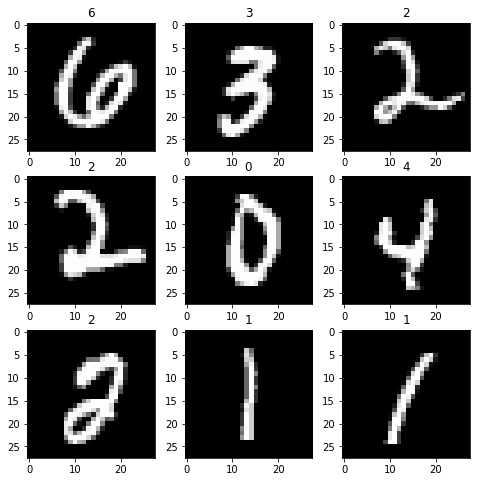

In [30]:
figure = plt.figure(figsize=(8,8))
cols,rows = 3,3
for i in range(1,cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset),size=(1,)).item()
#     print("sample_idx = ",sample_idx)
    img,label = train_dataset[sample_idx]
    figure.add_subplot(rows,cols,i)
    plt.title(label)
    plt.imshow(img.squeeze().numpy(),cmap="gray")